# Smart School Project — Prédiction des échecs étudiants
Exploration des données (EDA) et comparaison de modèles de régression pour prédire le `score_examen`.

## Imports

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import issparse
from scipy.stats import gaussian_kde
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor

## Constantes et paramètres

In [4]:
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']
MI_SAMPLE_SIZE = 50_000

small_dataset = False  # Mettre True pour tester sur 10 000 lignes seulement

## 1. Chargement des données

In [5]:
if small_dataset:
    df = pd.read_csv('student_dataset/student_failure/train.csv', nrows=10000)
else:
    df = pd.read_csv('student_dataset/student_failure/train.csv')

df.head(10)

,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94
5,5,24,male,Marketing,5.04,85.1,yes,9.4,average,online videos,medium,moderate,70.10,5,1.71
6,6,20,male,Computer Science,4.28,87.0,no,9.1,average,mixed,high,moderate,59.58,2,1.77
7,7,22,female,Bachelor of Arts,4.19,44.9,yes,8.8,good,self-study,high,hard,78.70,5,1.69
8,8,22,female,Marketing,1.06,98.3,yes,5.0,poor,mixed,low,moderate,49.68,3,1.74
9,9,18,male,Business Administration,3.44,80.9,yes,6.2,good,group study,medium,easy,58.20,5,1.84


## 2. Préparation des données
`X_train_orig` conserve le DataFrame brut avant encodage (utilisé pour le feature engineering MI au graphe 5).

In [6]:
y = df['score_examen']
X = df.drop(['score_examen', 'id', 'taille_etudiant'], axis=1)

# Split 3-voies : 60 % train / 20 % validation / 20 % test
# X_test est gardé strictement pour l'évaluation finale (jamais touché pendant l'entraînement)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=0  # 0.25 × 0.80 = 0.20
)
print(f'Train  : {X_train.shape}  ({len(X_train)/len(X):.0%})')
print(f'Val    : {X_valid.shape}  ({len(X_valid)/len(X):.0%})')
print(f'Test   : {X_test.shape}   ({len(X_test)/len(X):.0%})')

X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()

Train  : (378000, 12)  (60%)
Val    : (126000, 12)  (20%)
Test   : (126000, 12)   (20%)


## 3. Encodage des variables catégorielles
Changer `method` pour comparer les stratégies d'encodage.

| method | MAE full dataset |
|--------|------------------|
| `drop_categorical` ||
| `ordinal_encoding_random` ||
| `ordinal_encoding_smart` ||
| `one_hot_encoding_1` ||
| `one_hot_encoding_2` ||
| `ordinal_and_one_hot_encoding` ||

In [7]:
method = 'ordinal_and_one_hot_encoding'

if method == 'drop_categorical':
    X_train = X_train.select_dtypes(exclude=['str'])
    X_valid = X_valid.select_dtypes(exclude=['str'])
    X_test  = X_test.select_dtypes(exclude=['str'])

elif method == 'ordinal_encoding_random':
    obj_mask = X_train.dtypes == 'str'
    object_cols = list(obj_mask[obj_mask].index)
    ordinal_encoder = OrdinalEncoder()
    X_train[object_cols] = ordinal_encoder.fit_transform(X_train[object_cols])
    X_valid[object_cols] = ordinal_encoder.transform(X_valid[object_cols])
    X_test[object_cols]  = ordinal_encoder.transform(X_test[object_cols])

elif method == 'ordinal_encoding_smart':
    manual_encoder = OrdinalEncoder(categories=[
        ['poor', 'average', 'good'],
        ['low',  'medium',  'high'],
        ['easy', 'moderate', 'hard']
    ])
    auto_encoder = OrdinalEncoder(categories='auto')
    preprocessor = ColumnTransformer(transformers=[
        ('ord_manuel', manual_encoder,
         ['qualité_sommeil', 'évaluation_établissement', 'difficulté_examen']),
        ('ord_auto',   auto_encoder,
         ['genre', 'diplôme', 'accès_internet', 'méthode_etude'])
    ], remainder='passthrough')
    X_train = preprocessor.fit_transform(X_train)
    X_valid = preprocessor.transform(X_valid)
    X_test  = preprocessor.transform(X_test)

elif method == 'one_hot_encoding_1':
    X_train = pd.get_dummies(X_train)
    X_valid = pd.get_dummies(X_valid)
    X_test  = pd.get_dummies(X_test)
    X_train, X_valid = X_train.align(X_valid, join='left', axis=1)
    X_train, X_test  = X_train.align(X_test,  join='left', axis=1)

elif method == 'one_hot_encoding_2':
    obj_mask = X_train.dtypes == 'str'
    object_cols = list(obj_mask[obj_mask].index)
    one_hot_encoder = OneHotEncoder()
    preprocessor = ColumnTransformer(
        transformers=[('onehot', one_hot_encoder, object_cols)],
        remainder='passthrough'
    )
    X_train = preprocessor.fit_transform(X_train)
    X_valid = preprocessor.transform(X_valid)
    X_test  = preprocessor.transform(X_test)

elif method == 'ordinal_and_one_hot_encoding':
    manual_ordinal_cols = ['qualité_sommeil', 'évaluation_établissement', 'difficulté_examen']
    one_hot_cols        = ['genre', 'diplôme', 'accès_internet', 'méthode_etude']
    ordinal_encoder = OrdinalEncoder(categories=[
        ['poor', 'average', 'good'],
        ['low',  'medium',  'high'],
        ['easy', 'moderate', 'hard']
    ])
    one_hot_encoder = OneHotEncoder(sparse_output=False)
    preprocessor = ColumnTransformer(transformers=[
        ('ordinal', ordinal_encoder, manual_ordinal_cols),
        ('onehot',  one_hot_encoder, one_hot_cols)
    ], remainder='passthrough')
    X_train = preprocessor.fit_transform(X_train)
    X_valid = preprocessor.transform(X_valid)
    X_test  = preprocessor.transform(X_test)

else:
    raise ValueError("Méthode d'encodage inconnue.")

print('Shape après preprocessing — train:', X_train.shape, '  val:', X_valid.shape, '  test:', X_test.shape)

Shape après preprocessing — train: (378000, 26)   val: (126000, 26)   test: (126000, 26)


In [8]:
X_train_dense = X_train.toarray() if issparse(X_train) else np.array(X_train)
X_valid_dense = X_valid.toarray() if issparse(X_valid) else np.array(X_valid)
X_test_dense  = X_test.toarray()  if issparse(X_test)  else np.array(X_test)

imputer = SimpleImputer(strategy='median')  # 'median' est une stratégie d'imputation qui remplace les valeurs manquantes par la valeur médiane de la colonne
X_train_dense = imputer.fit_transform(X_train_dense)
X_valid_dense = imputer.transform(X_valid_dense)
X_test_dense  = imputer.transform(X_test_dense)

## 4. Entraînement des modèles

In [9]:
baseline_pred = np.full(len(y_valid), y_train.mean())
mae_baseline  = mean_absolute_error(baseline_pred, y_valid)
print(f'Baseline (moyenne)         MAE : {mae_baseline:.4f}')

Baseline (moyenne)         MAE : 15.6232


In [10]:
lr = LinearRegression()
lr.fit(X_train_dense, y_train)
mae_lr = mean_absolute_error(lr.predict(X_valid_dense), y_valid)
print(f'Régression linéaire        MAE : {mae_lr:.4f}')

Régression linéaire        MAE : 7.3502


In [11]:
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=4)
rf.fit(X_train_dense, y_train)
mae_rf = mean_absolute_error(rf.predict(X_valid_dense), y_valid)
print(f'Random Forest              MAE : {mae_rf:.4f}')

Random Forest              MAE : 7.5565


In [12]:
model_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=4,
    early_stopping_rounds=50,
    eval_metric='rmse'
)
model_xgb.fit(
    X_train_dense, y_train,
    eval_set=[(X_valid_dense, y_valid)],
    verbose=False
)
mae_xgb = mean_absolute_error(model_xgb.predict(X_valid_dense), y_valid)
print(f'XGBoost                    MAE : {mae_xgb:.4f}')

XGBoost                    MAE : 7.2407


In [13]:
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train_dense)
X_valid_scaled = scaler_mlp.transform(X_valid_dense)

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
mlp.fit(X_train_scaled, y_train)
mae_mlp = mean_absolute_error(mlp.predict(X_valid_scaled), y_valid)
print(f'MLP (réseau de neurones)   MAE : {mae_mlp:.4f}')

MLP (réseau de neurones)   MAE : 7.3710


## 4b. Évaluation finale sur le test set et Cross-Validation (5-fold)

Le **test set** (20 % des données, jamais vu pendant l'entraînement) sert à l'évaluation finale.  
La **cross-validation 5-fold** est réalisée sur un échantillon stratifié du train set via des pipelines sklearn, garantissant qu'aucune fuite de données ne se produit entre les folds.

In [14]:
# --- Évaluation sur le test set (évaluation finale, modèles déjà entraînés) ---
X_test_scaled = scaler_mlp.transform(X_test_dense)

mae_test_baseline = mean_absolute_error(np.full(len(y_test), y_train.mean()), y_test)
mae_test_lr       = mean_absolute_error(lr.predict(X_test_dense),  y_test)
mae_test_rf       = mean_absolute_error(rf.predict(X_test_dense),  y_test)
mae_test_xgb      = mean_absolute_error(model_xgb.predict(X_test_dense), y_test)
mae_test_mlp      = mean_absolute_error(mlp.predict(X_test_scaled), y_test)

print('=== MAE sur le TEST SET (évaluation finale) ===')
for name, val_mae, test_mae in [
    ('Baseline (moyenne)',       mae_baseline, mae_test_baseline),
    ('Régression linéaire',      mae_lr,       mae_test_lr),
    ('Random Forest',            mae_rf,       mae_test_rf),
    ('XGBoost',                  mae_xgb,      mae_test_xgb),
    ('MLP (réseau de neurones)', mae_mlp,      mae_test_mlp),
]:
    print(f'{name:<28}  Val: {val_mae:.4f}  |  Test: {test_mae:.4f}')

=== MAE sur le TEST SET (évaluation finale) ===
Baseline (moyenne)            Val: 15.6232  |  Test: 15.5901
Régression linéaire           Val: 7.3502  |  Test: 7.3294
Random Forest                 Val: 7.5565  |  Test: 7.5321
XGBoost                       Val: 7.2407  |  Test: 7.2230
MLP (réseau de neurones)      Val: 7.3710  |  Test: 7.3473


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold

CV_SAMPLE_SIZE = 60_000  # Échantillon stratifié : dataset trop grand (504 K lignes) pour une CV complète

# Échantillonnage stratifié sur pass/fail pour conserver les proportions
_, X_cv, _, y_cv = train_test_split(
    X_train_orig.reset_index(drop=True),
    y_train.reset_index(drop=True),
    test_size=CV_SAMPLE_SIZE / len(y_train),
    stratify=(y_train.reset_index(drop=True) < 50).astype(int),
    random_state=42
)
X_cv = X_cv.reset_index(drop=True)
y_cv = y_cv.reset_index(drop=True)
print(f'Échantillon CV : {len(X_cv):,} lignes — '
      f'{(y_cv < 50).sum():,} échecs / {(y_cv >= 50).sum():,} réussites')

def make_preprocessor():
    """Retourne un ColumnTransformer non entraîné pour une utilisation dans un Pipeline CV."""
    return ColumnTransformer(transformers=[
        ('ordinal', OrdinalEncoder(categories=[
            ['poor', 'average', 'good'],
            ['low',  'medium',  'high'],
            ['easy', 'moderate', 'hard']
        ]), ['qualité_sommeil', 'évaluation_établissement', 'difficulté_examen']),
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
         ['genre', 'diplôme', 'accès_internet', 'méthode_etude'])
    ], remainder='passthrough')

cv_pipelines = {
    'Régression Linéaire': Pipeline([
        ('pre', make_preprocessor()),
        ('imp', SimpleImputer(strategy='median')),
        ('model', LinearRegression())
    ]),
    'Random Forest': Pipeline([
        ('pre', make_preprocessor()),
        ('imp', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=4))
    ]),
    'XGBoost': Pipeline([
        ('pre', make_preprocessor()),
        ('imp', SimpleImputer(strategy='median')),
        ('model', XGBRegressor(n_estimators=300, learning_rate=0.05,
                               n_jobs=4, random_state=42))
    ]),
    'MLP': Pipeline([
        ('pre', make_preprocessor()),
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu',
                               max_iter=300, random_state=42,
                               early_stopping=True, validation_fraction=0.1,
                               n_iter_no_change=20))
    ]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

# Baseline (calculé manuellement fold par fold)
baseline_cv = []
for tr_idx, vl_idx in kf.split(X_cv):
    pred = np.full(len(vl_idx), y_cv.iloc[tr_idx].mean())
    baseline_cv.append(mean_absolute_error(y_cv.iloc[vl_idx], pred))
cv_scores['Baseline (moyenne)'] = baseline_cv
print(f"{'Baseline (moyenne)':<22}  CV MAE : {np.mean(baseline_cv):.4f} ± {np.std(baseline_cv):.4f}")

for name, pipeline in cv_pipelines.items():
    print(f'Calcul CV — {name}...', end=' ', flush=True)
    scores = -cross_val_score(pipeline, X_cv, y_cv,
                              cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_scores[name] = list(scores)
    print(f'CV MAE : {scores.mean():.4f} ± {scores.std():.4f}')

Échantillon CV : 60,000 lignes — 15,347 échecs / 44,653 réussites
Baseline (moyenne)      CV MAE : 15.6111 ± 0.0668
Calcul CV — Régression Linéaire... CV MAE : 7.3086 ± 0.0422
Calcul CV — Random Forest... CV MAE : 7.5745 ± 0.0480
Calcul CV — XGBoost... CV MAE : 7.3022 ± 0.0405
Calcul CV — MLP... CV MAE : 7.4230 ± 0.0486


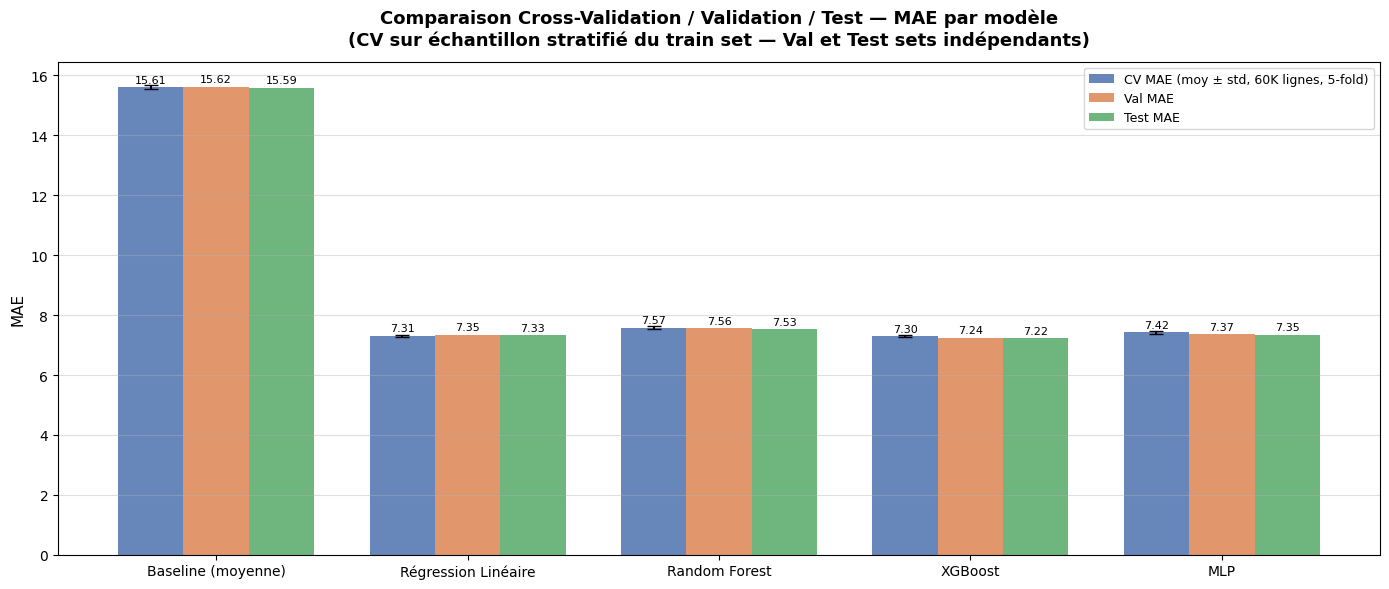


              Modèle CV MAE (moy) CV MAE (std) Val MAE Test MAE
 Baseline (moyenne)      15.6111       0.0668 15.6232  15.5901
Régression Linéaire       7.3086       0.0422  7.3502   7.3294
      Random Forest       7.5745       0.0480  7.5565   7.5321
            XGBoost       7.3022       0.0405  7.2407   7.2230
                MLP       7.4230       0.0486  7.3710   7.3473


In [16]:
# Graphe récapitulatif : CV MAE (avec barres d'erreur) + Val MAE + Test MAE
mae_val_map  = {
    'Baseline (moyenne)':  mae_baseline,
    'Régression Linéaire': mae_lr,
    'Random Forest':       mae_rf,
    'XGBoost':             mae_xgb,
    'MLP':                 mae_mlp,
}
mae_test_map = {
    'Baseline (moyenne)':  mae_test_baseline,
    'Régression Linéaire': mae_test_lr,
    'Random Forest':       mae_test_rf,
    'XGBoost':             mae_test_xgb,
    'MLP':                 mae_test_mlp,
}

names_order = list(cv_scores.keys())
cv_means = [np.mean(cv_scores[n]) for n in names_order]
cv_stds  = [np.std(cv_scores[n])  for n in names_order]
val_maes = [mae_val_map[n]         for n in names_order]
test_maes= [mae_test_map[n]        for n in names_order]

x = np.arange(len(names_order))
w = 0.26

fig_cv, ax_cv = plt.subplots(figsize=(14, 6))
b1 = ax_cv.bar(x - w, cv_means, w, yerr=cv_stds, capsize=5,
               label=f'CV MAE (moy ± std, {CV_SAMPLE_SIZE//1000}K lignes, 5-fold)',
               color=PALETTE[0], alpha=0.85)
b2 = ax_cv.bar(x,     val_maes,  w, label='Val MAE',  color=PALETTE[1], alpha=0.85)
b3 = ax_cv.bar(x + w, test_maes, w, label='Test MAE', color=PALETTE[2], alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax_cv.text(bar.get_x() + bar.get_width() / 2, h + 0.08,
                   f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax_cv.set_xticks(x)
ax_cv.set_xticklabels(names_order, fontsize=10)
ax_cv.set_ylabel('MAE', fontsize=11)
ax_cv.set_title(
    'Comparaison Cross-Validation / Validation / Test — MAE par modèle\n'
    '(CV sur échantillon stratifié du train set — Val et Test sets indépendants)',
    fontsize=13, fontweight='bold', pad=12
)
ax_cv.legend(fontsize=9)
ax_cv.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
summary = pd.DataFrame({
    'Modèle':        names_order,
    'CV MAE (moy)':  [f'{np.mean(cv_scores[n]):.4f}' for n in names_order],
    'CV MAE (std)':  [f'{np.std(cv_scores[n]):.4f}'  for n in names_order],
    'Val MAE':       [f'{mae_val_map[n]:.4f}'          for n in names_order],
    'Test MAE':      [f'{mae_test_map[n]:.4f}'         for n in names_order],
})
print('\n', summary.to_string(index=False))

## 5. Graphes EDA
Initialisation commune : thème seaborn et noms de features partagés entre les graphes 4, 5 et 8.

In [17]:
sns.set_theme(style='whitegrid')

try:
    raw_names = preprocessor.get_feature_names_out()
    feat_names_base = [n.split('__', 1)[-1] for n in raw_names]
except Exception:
    feat_names_base = [f'feature_{i}' for i in range(X_train_dense.shape[1])]

### Graphe 1 — Valeurs manquantes par colonne

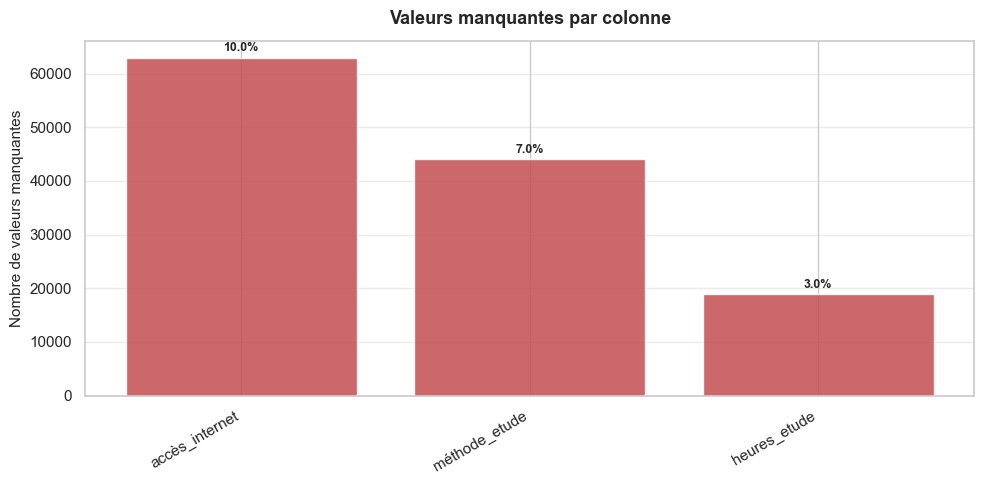

In [18]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig0, ax0 = plt.subplots(figsize=(10, 5))
if missing.empty:
    ax0.text(0.5, 0.5, 'Aucune valeur manquante dans le dataset',
             ha='center', va='center', fontsize=14, color='green',
             transform=ax0.transAxes)
else:
    bars0 = ax0.bar(missing.index, missing.values, color=PALETTE[3], alpha=0.85)
    for bar, val in zip(bars0, missing.values):
        ax0.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + missing.max() * 0.01,
                 f'{val / len(df):.1%}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax0.set_ylabel('Nombre de valeurs manquantes', fontsize=11)
    plt.xticks(rotation=30, ha='right')

ax0.set_title('Valeurs manquantes par colonne', fontsize=13, fontweight='bold', pad=12)
ax0.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### Graphe 2 — Distribution des scores d'examen

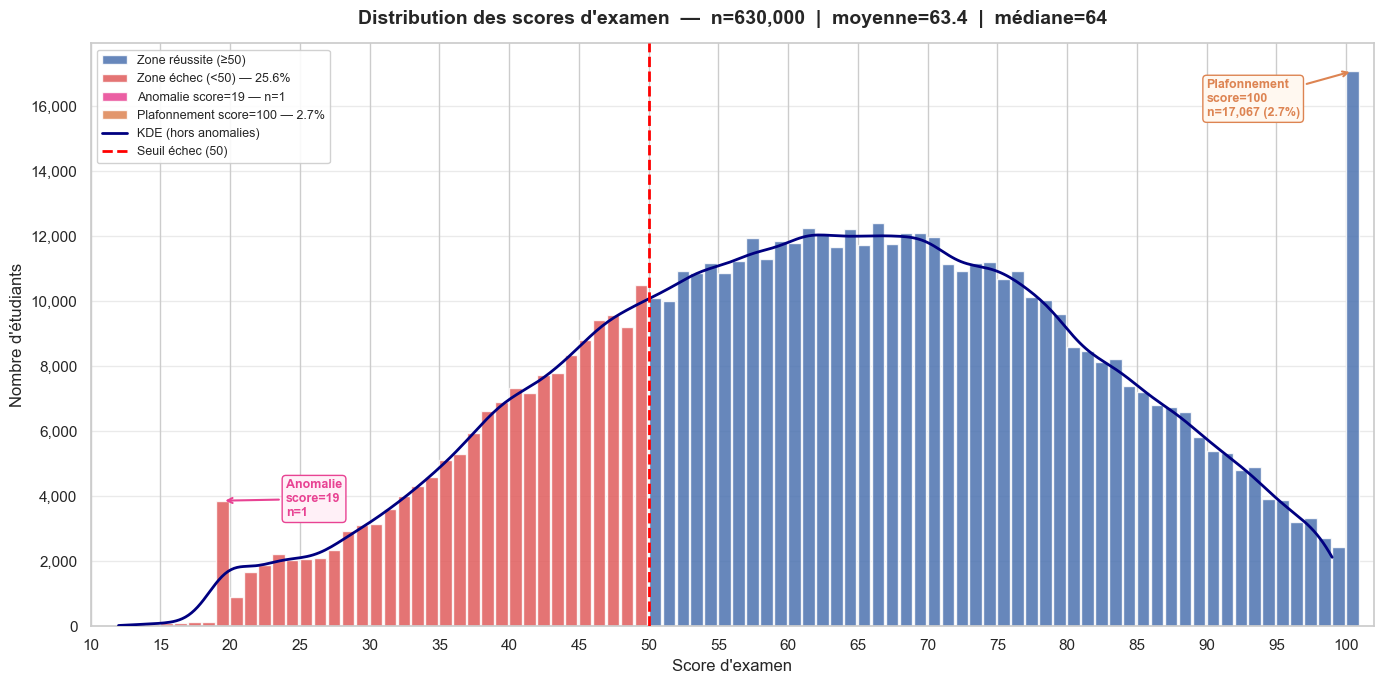

In [19]:
s = df['score_examen']
n_total = len(s)
n_100   = (s == 100).sum()
n_fail  = (s < 50).sum()
n_19    = (s == 19).sum()

counts, edges = np.histogram(s, bins=np.arange(12, 102, 1))

fig1, ax1 = plt.subplots(figsize=(14, 7))

bar_colors = []
for left, right in zip(edges[:-1], edges[1:]):
    mid = (left + right) / 2
    if mid == 19:    bar_colors.append('#E84393')
    elif mid == 100: bar_colors.append('#DD8452')
    elif mid < 50:   bar_colors.append('#E05C5C')
    else:            bar_colors.append('#4C72B0')

ax1.bar(edges[:-1], counts, width=0.9, color=bar_colors, alpha=0.85, align='edge', zorder=2)

s_kde = s[(s != 100) & (s != 19)]
kde = gaussian_kde(s_kde, bw_method=0.08)
x_kde = np.linspace(12, 99, 400)
kde_vals = kde(x_kde) * len(s_kde)
ax1.plot(x_kde, kde_vals, color='navy', linewidth=2.0, label='KDE (hors anomalies)', zorder=3)

ax1.axvline(50, color='red', linestyle='--', linewidth=2,
            label=f'Seuil échec 50 — {n_fail:,} étudiants ({n_fail/n_total:.1%})', zorder=4)

idx_19 = np.where(edges[:-1] == 19)[0]
if len(idx_19):
    h19 = counts[idx_19[0]]
    ax1.annotate(
        f'Anomalie\nscore=19\nn={n_19:,}',
        xy=(19.45, h19), xytext=(24, h19 * 0.88),
        fontsize=9, color='#E84393', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#E84393', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f7', ec='#E84393', lw=1)
    )

ax1.annotate(
    f'Plafonnement\nscore=100\nn={n_100:,} ({n_100/n_total:.1%})',
    xy=(100.45, n_100), xytext=(90, n_100 * 0.92),
    fontsize=9, color='#DD8452', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#DD8452', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff8f0', ec='#DD8452', lw=1)
)

legend_elements = [
    mpatches.Patch(facecolor='#4C72B0', alpha=0.85, label='Zone réussite (≥50)'),
    mpatches.Patch(facecolor='#E05C5C', alpha=0.85, label=f'Zone échec (<50) — {n_fail/n_total:.1%}'),
    mpatches.Patch(facecolor='#E84393', alpha=0.85, label=f'Anomalie score=19 — n={n_19:,}'),
    mpatches.Patch(facecolor='#DD8452', alpha=0.85, label=f'Plafonnement score=100 — {n_100/n_total:.1%}'),
    plt.Line2D([0], [0], color='navy', linewidth=2, label='KDE (hors anomalies)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='Seuil échec (50)'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)
ax1.set_title(
    f"Distribution des scores d'examen  —  n={n_total:,}"
    f'  |  moyenne={s.mean():.1f}  |  médiane={s.median():.0f}',
    fontsize=14, fontweight='bold', pad=14
)
ax1.set_xlabel("Score d'examen", fontsize=12)
ax1.set_ylabel("Nombre d'étudiants", fontsize=12)
ax1.set_xlim(10, 102)
ax1.set_xticks(range(10, 101, 5))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(axis='y', alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

### Graphe 3 — Score d'examen selon les variables catégorielles

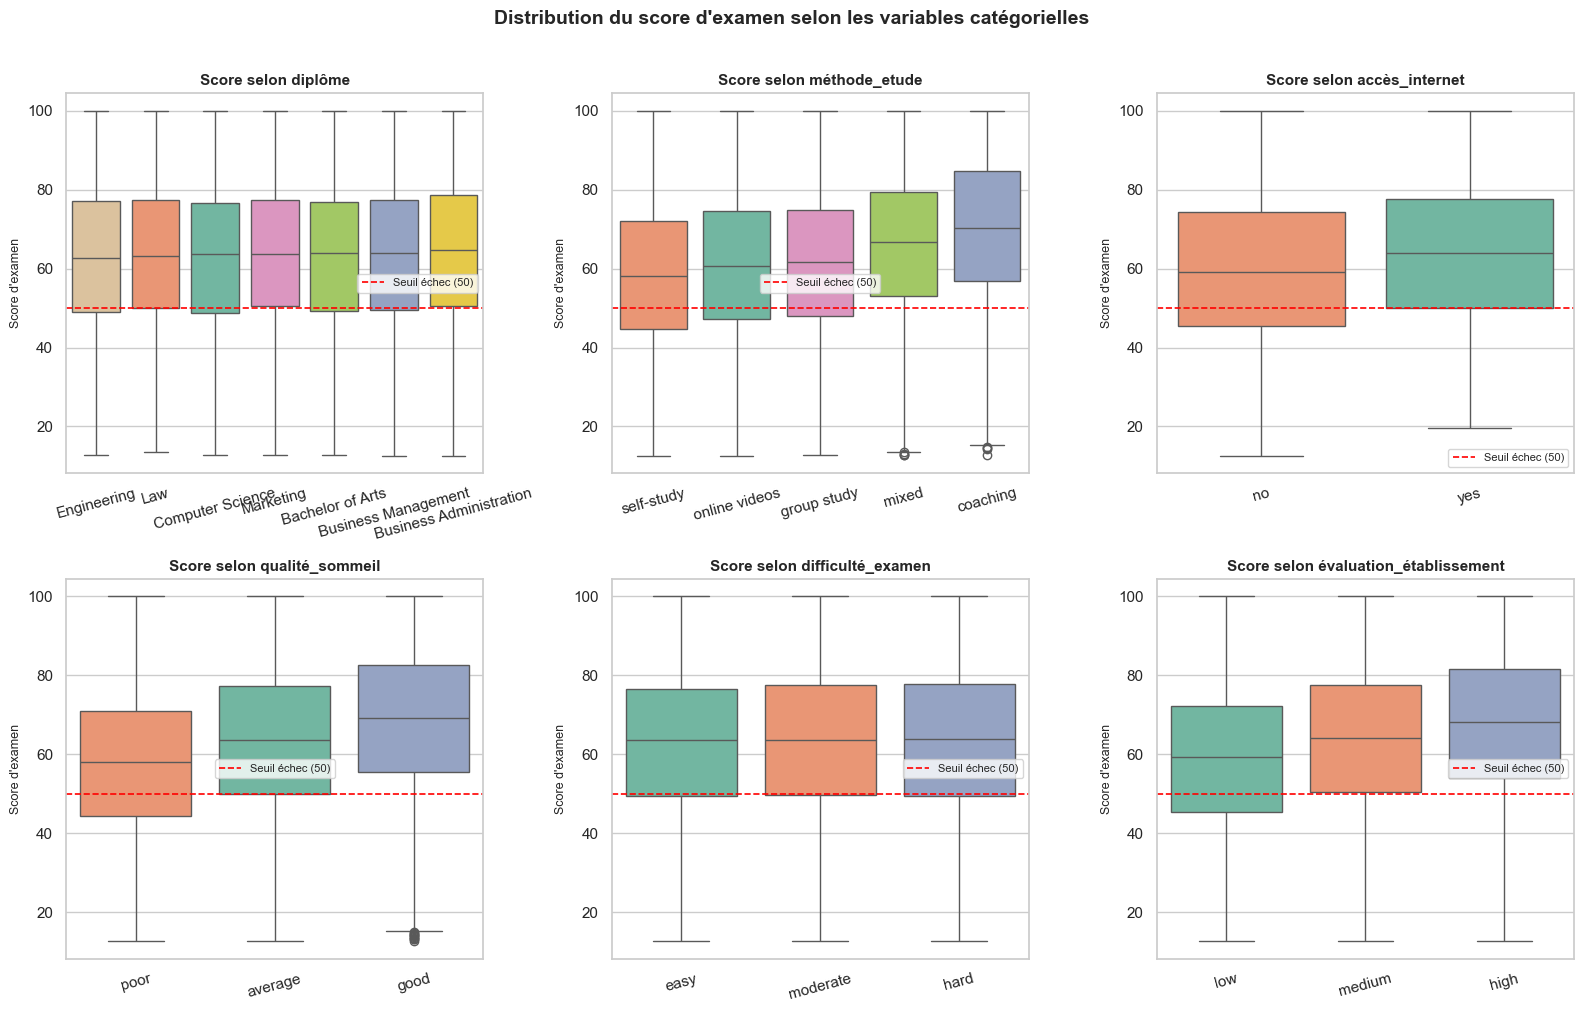

In [20]:
cat_cols = [
    'diplôme', 'méthode_etude', 'accès_internet',
    'qualité_sommeil', 'difficulté_examen', 'évaluation_établissement'
]
fig3, axes3 = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes3.flat, cat_cols):
    order = df.groupby(col)['score_examen'].median().sort_values().index
    sns.boxplot(data=df, x=col, y='score_examen',
                order=order, ax=ax, hue=col, palette='Set2', legend=False)
    ax.axhline(50, color='red', linestyle='--', linewidth=1.2, label='Seuil échec (50)')
    ax.set_title(f'Score selon {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel("Score d'examen", fontsize=9)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)

fig3.suptitle(
    "Distribution du score d'examen selon les variables catégorielles",
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

### Graphe 4 — Matrice de corrélation (toutes les variables après encodage)
Réutilise `X_train_dense` et `feat_names_base` — aucun ré-encodage nécessaire. `score_examen` est ajouté comme dernière colonne.

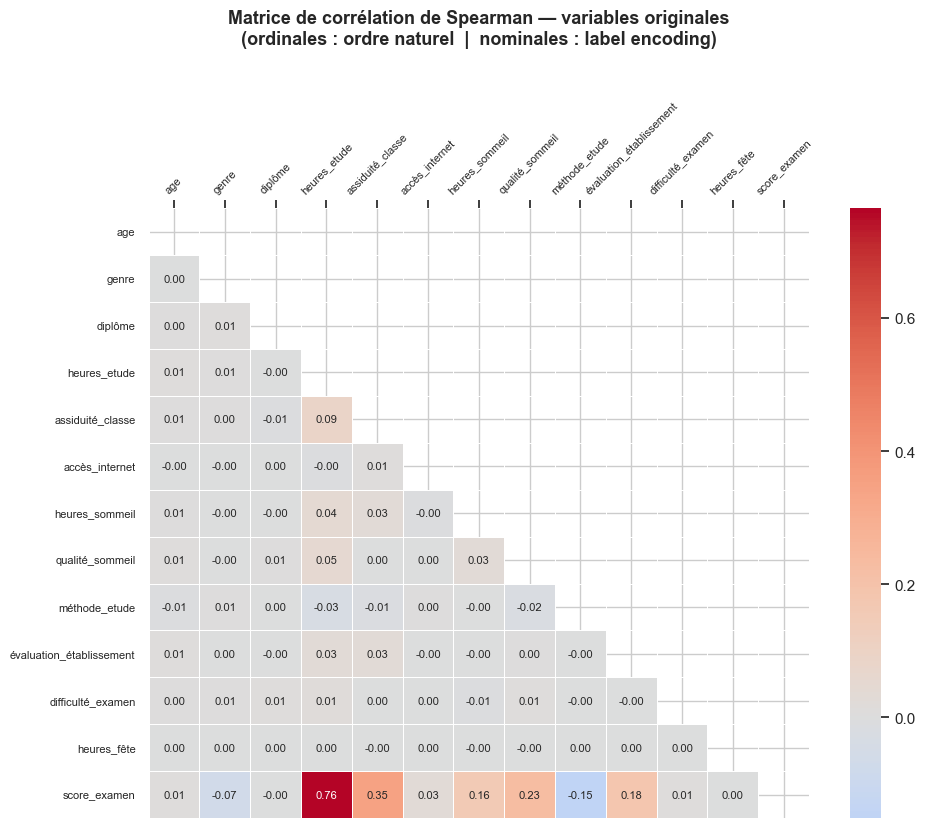

In [21]:
from sklearn.preprocessing import LabelEncoder

# Choisir le mode d'affichage de la matrice de corrélation :
#   'compact'  → variables originales (13 colonnes), corrélation Spearman
#   'expanded' → toutes les colonnes après encodage OHE (27 colonnes), corrélation Pearson
corr_mode = 'compact'

if corr_mode == 'compact':
    df_corr = X_train_orig.copy()
    df_corr['score_examen'] = y_train.values

    # Ordinales : ordre naturel préservé
    for col, mapping in {
        'qualité_sommeil':          {'poor': 0, 'average': 1, 'good': 2},
        'évaluation_établissement': {'low':  0, 'medium':  1, 'high': 2},
        'difficulté_examen':        {'easy': 0, 'moderate': 1, 'hard': 2},
    }.items():
        df_corr[col] = df_corr[col].map(mapping)

    # Nominales : label encoding (1 seule colonne par variable)
    le = LabelEncoder()
    for col in ['genre', 'diplôme', 'accès_internet', 'méthode_etude']:
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))

    corr_matrix = df_corr.corr(method='spearman')
    title = 'Matrice de corrélation de Spearman — variables originales\n(ordinales : ordre naturel  |  nominales : label encoding)'

else:  # 'expanded'
    df_corr = pd.DataFrame(X_train_dense, columns=feat_names_base)
    df_corr['score_examen'] = y_train.values
    corr_matrix = df_corr.corr(method='pearson')
    title = 'Matrice de corrélation de Pearson — toutes les colonnes après encodage OHE'

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

n_feats  = len(df_corr.columns)
fig_w    = max(10, n_feats * 0.75)
fig_h    = max(8,  n_feats * 0.65)
annot_sz = max(6, 11 - n_feats // 4)

fig4, ax4 = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.4, ax=ax4,
    annot_kws={'size': annot_sz}
)
ax4.xaxis.tick_top()
ax4.xaxis.set_label_position('top')
ax4.set_title(title, fontsize=13, fontweight='bold', pad=40)
ax4.tick_params(axis='x', rotation=45, labelsize=annot_sz)
ax4.tick_params(axis='y', labelsize=annot_sz)
plt.tight_layout()
plt.show()

### Graphe 5 — Importance des features (Mutual Information)
Réutilise `X_train_dense` + 3 features engineered calculées depuis `X_train_orig`.

Échantillonnage : 50,000 / 378,000 lignes (13%) pour accélérer le calcul MI...
Calcul Mutual Information (26 features, 49,999 lignes)...
Calcul MI terminé.


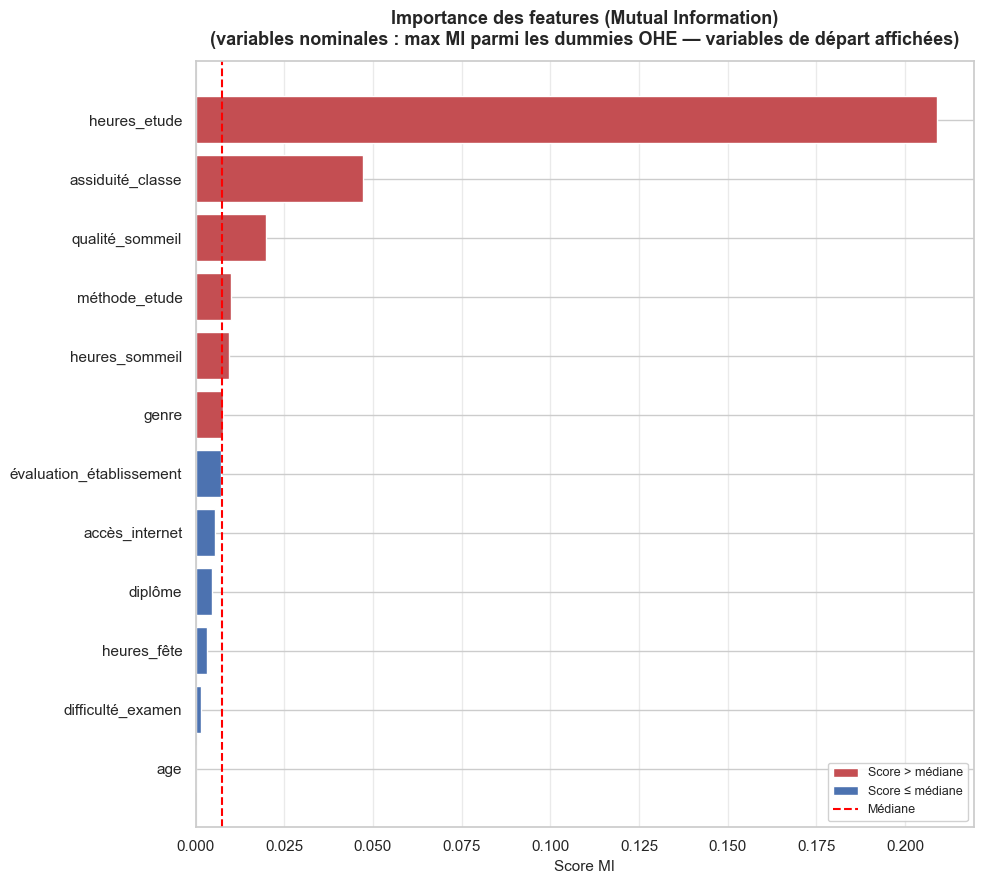

In [26]:
X_mi = pd.DataFrame(X_train_dense, columns=feat_names_base).fillna(0).astype(float)
y_mi = (y_train < 50).astype(int).reset_index(drop=True)

n_rows = len(X_mi)
if n_rows > MI_SAMPLE_SIZE:
    print(f'Échantillonnage : {MI_SAMPLE_SIZE:,} / {n_rows:,} lignes '
          f'({MI_SAMPLE_SIZE/n_rows:.0%}) pour accélérer le calcul MI...')
    sample_idx = (
        pd.DataFrame({'y': y_mi})
        .groupby('y', group_keys=False)
        .apply(lambda g: g.sample(
            n=int(MI_SAMPLE_SIZE * len(g) / n_rows),
            random_state=42
        ), include_groups=False)
        .index
    )
    X_mi_sample = X_mi.loc[sample_idx]
    y_mi_sample = y_mi.loc[sample_idx]
else:
    X_mi_sample = X_mi
    y_mi_sample = y_mi

print(f'Calcul Mutual Information ({X_mi.shape[1]} features, {len(X_mi_sample):,} lignes)...')
mi = mutual_info_classif(X_mi_sample, y_mi_sample, random_state=42, n_neighbors=3)

# Variables nominales encodées en OHE → regrouper les dummies par variable originale.
# On calcule le MI sur toutes les colonnes expansées (précision maximale),
# puis on prend le max des scores parmi les dummies d'une même variable pour l'affichage.
one_hot_cols_orig = ['genre', 'diplôme', 'accès_internet', 'méthode_etude']

def _orig_name(feat, ohe_cols):
    for col in ohe_cols:
        if feat.startswith(col + '_'):
            return col
    return feat

mi_dict = {}
for feat, score in zip(feat_names_base, mi):
    key = _orig_name(feat, one_hot_cols_orig)
    mi_dict.setdefault(key, []).append(score)

mi_series = pd.Series({k: max(v) for k, v in mi_dict.items()}).sort_values(ascending=True)
print('Calcul MI terminé.')

fig5, ax5 = plt.subplots(figsize=(10, 9))
mi_colors = [PALETTE[3] if v > mi_series.median() else PALETTE[0] for v in mi_series.values]
ax5.barh(mi_series.index, mi_series.values, color=mi_colors)
ax5.axvline(mi_series.median(), color='red', linestyle='--', linewidth=1.5)
legend_mi = [
    mpatches.Patch(facecolor=PALETTE[3], label='Score > médiane'),
    mpatches.Patch(facecolor=PALETTE[0], label='Score ≤ médiane'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label='Médiane'),
]
ax5.legend(handles=legend_mi, fontsize=9, framealpha=0.9)
ax5.set_title(
    'Importance des features (Mutual Information)\n'
    '(variables nominales : max MI parmi les dummies OHE — variables de départ affichées)',
    fontsize=13, fontweight='bold', pad=12
)
ax5.set_xlabel('Score MI', fontsize=11)
ax5.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Résultats des modèles

### Graphe 6 — Comparaison des modèles (MAE)

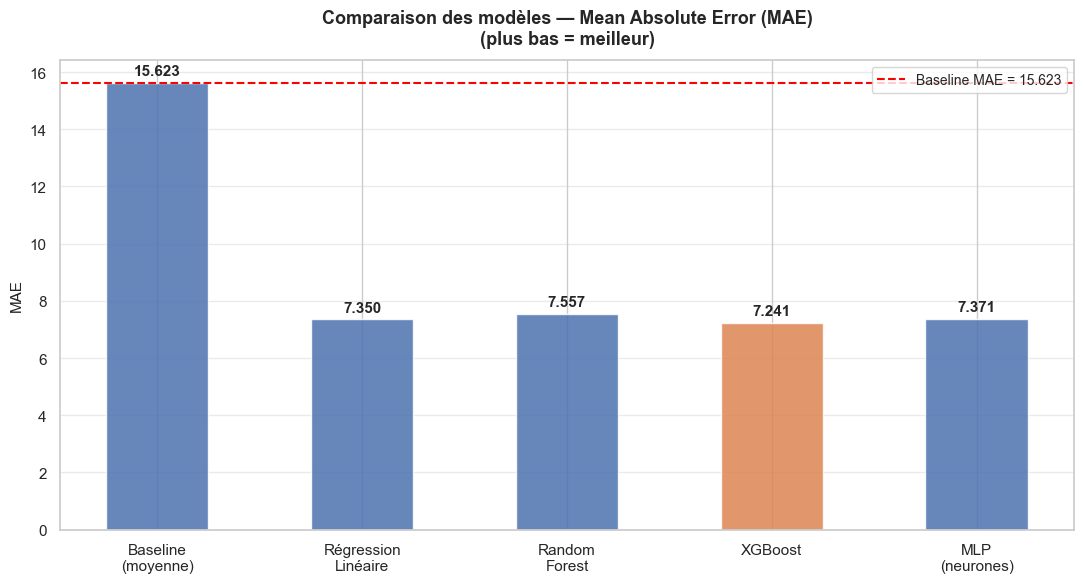

In [23]:
model_names = [
    'Baseline\n(moyenne)',
    'Régression\nLinéaire',
    'Random\nForest',
    'XGBoost',
    'MLP\n(neurones)'
]
model_maes = [mae_baseline, mae_lr, mae_rf, mae_xgb, mae_mlp]

best_idx  = int(np.argmin(model_maes))
bar_cols6 = [PALETTE[1] if i == best_idx else PALETTE[0] for i in range(len(model_maes))]

fig6, ax6 = plt.subplots(figsize=(11, 6))
bars6 = ax6.bar(model_names, model_maes, color=bar_cols6, alpha=0.85, width=0.5)

for bar, mae in zip(bars6, model_maes):
    ax6.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(model_maes) * 0.01,
        f'{mae:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax6.axhline(mae_baseline, color='red', linestyle='--', linewidth=1.5,
            label=f'Baseline MAE = {mae_baseline:.3f}')
ax6.set_title(
    'Comparaison des modèles — Mean Absolute Error (MAE)\n(plus bas = meilleur)',
    fontsize=13, fontweight='bold', pad=12
)
ax6.set_ylabel('MAE', fontsize=11)
ax6.legend(fontsize=10)
ax6.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### Graphe 7 — Courbe d'apprentissage XGBoost (RMSE vs rounds)

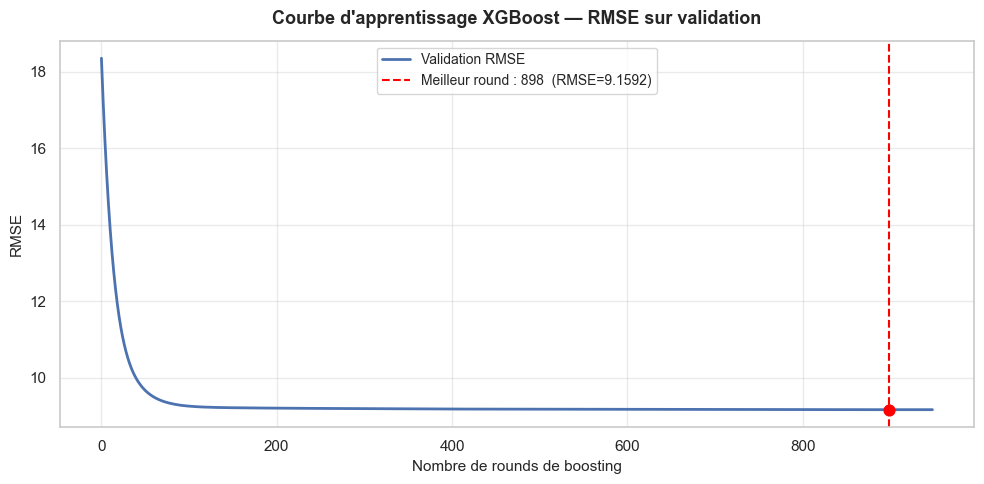

In [24]:
results = model_xgb.evals_result()
epochs  = len(results['validation_0']['rmse'])

fig7, ax7 = plt.subplots(figsize=(10, 5))
ax7.plot(range(epochs), results['validation_0']['rmse'],
         color=PALETTE[0], linewidth=2, label='Validation RMSE')

best_round = int(np.argmin(results['validation_0']['rmse']))
best_rmse  = results['validation_0']['rmse'][best_round]
ax7.axvline(best_round, color='red', linestyle='--', linewidth=1.5,
            label=f'Meilleur round : {best_round}  (RMSE={best_rmse:.4f})')
ax7.scatter([best_round], [best_rmse], color='red', zorder=5, s=60)
ax7.set_xlabel('Nombre de rounds de boosting', fontsize=11)
ax7.set_ylabel('RMSE', fontsize=11)
ax7.set_title("Courbe d'apprentissage XGBoost — RMSE sur validation",
              fontsize=13, fontweight='bold', pad=12)
ax7.legend(fontsize=10)
ax7.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Graphe 8 — Importance des features XGBoost (gain) — Top 20

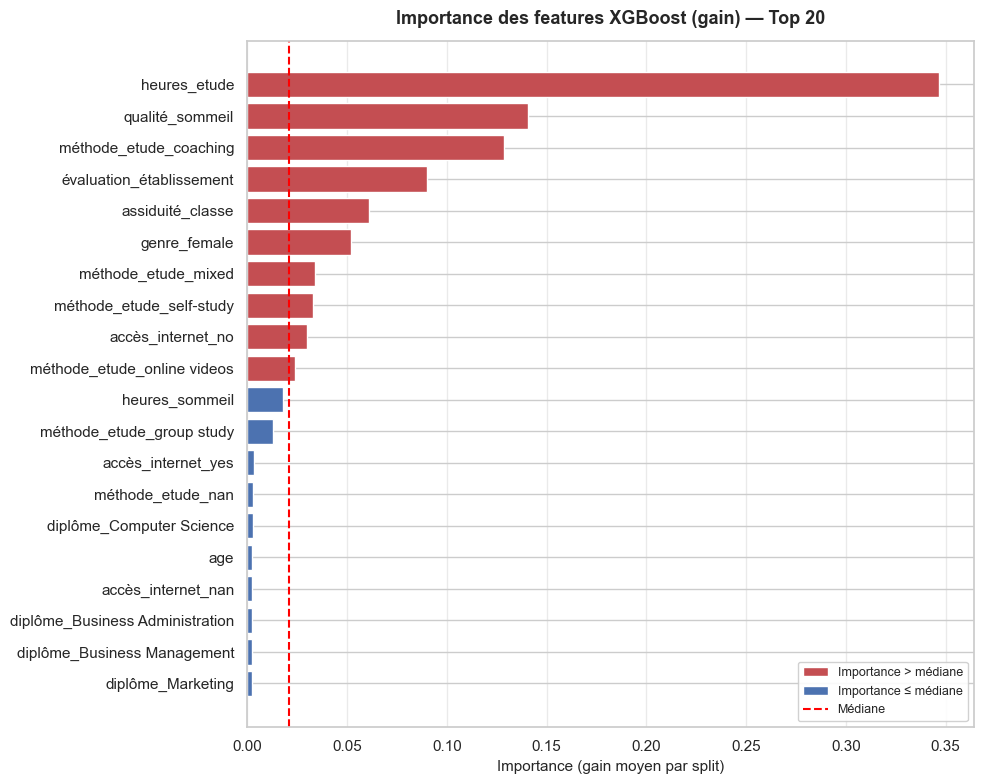

In [25]:
fi_vals   = model_xgb.feature_importances_
fi_series = pd.Series(fi_vals, index=feat_names_base).sort_values(ascending=True)
fi_top    = fi_series.tail(20)

fig8, ax8 = plt.subplots(figsize=(10, 8))
fi_colors = [PALETTE[3] if v > fi_top.median() else PALETTE[0] for v in fi_top.values]
ax8.barh(fi_top.index, fi_top.values, color=fi_colors)
ax8.axvline(fi_top.median(), color='red', linestyle='--', linewidth=1.5, label='Médiane')
legend_fi = [
    mpatches.Patch(facecolor=PALETTE[3], label='Importance > médiane'),
    mpatches.Patch(facecolor=PALETTE[0], label='Importance ≤ médiane'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label='Médiane'),
]
ax8.legend(handles=legend_fi, fontsize=9, framealpha=0.9)
ax8.set_title('Importance des features XGBoost (gain) — Top 20',
              fontsize=13, fontweight='bold', pad=12)
ax8.set_xlabel('Importance (gain moyen par split)', fontsize=11)
ax8.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()